In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

In [4]:
#load dataset
wine = pd.read_csv(r"C:\Users\hecto\Documents\PythonProjects\wine-clustering.csv")

wine.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
#info
wine.info()
wine.describe()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
#checking for missing values
wine.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

The dataset did not contain missing values, so no imputation or deletion was required before PCA or clustering.

In [7]:
#scale
scaler = StandardScaler()

wine_scaled = scaler.fit_transform(wine)

In [8]:
#PCA
pca = PCA()

pca_data = pca.fit_transform(wine_scaled)

explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

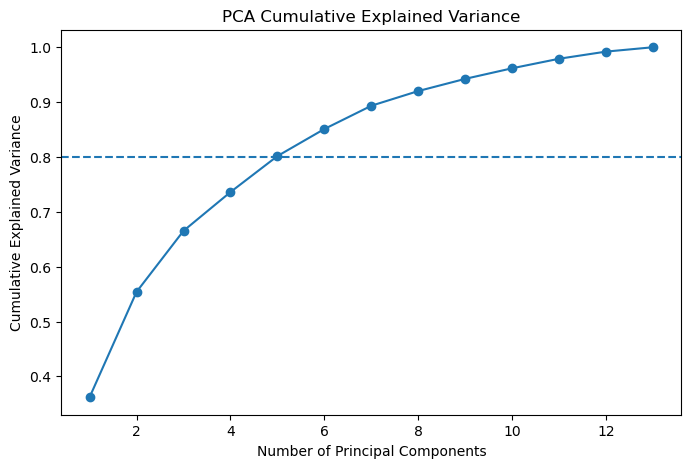

In [9]:
#cumulative variance plot
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.80, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.show()

In [11]:
#80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print("Number of components needed for 80% variance:", n_components_80)

Number of components needed for 80% variance: 5


In [12]:
#refit PCA
pca_80 = PCA(n_components=n_components_80)

wine_pca = pca_80.fit_transform(wine_scaled)

wine_pca_df = pd.DataFrame(
    wine_pca,
    columns=[f"PC{i+1}" for i in range(n_components_80)]
)

wine_pca_df.head()

,PC1,PC2,PC3,PC4,PC5
0,3.316751,1.443463,-0.165739,-0.215631,0.693043
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655
2,2.516740,1.031151,0.982819,0.724902,-0.251033
3,3.757066,2.756372,-0.176192,0.567983,-0.311842
4,1.008908,0.869831,2.026688,-0.409766,0.298458


In [13]:
#interpetation
loadings = pd.DataFrame(
    pca_80.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components_80)],
    index=wine.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5
Alcohol,0.144329,0.483652,-0.207383,-0.017856,-0.265664
Malic_Acid,-0.245188,0.224931,0.089013,0.536890,0.035214
Ash,-0.002051,0.316069,0.626224,-0.214176,-0.143025
Ash_Alcanity,-0.239320,-0.010591,0.612080,0.060859,0.066103
Magnesium,0.141992,0.299634,0.130757,-0.351797,0.727049
Total_Phenols,0.394661,0.065040,0.146179,0.198068,-0.149318
Flavanoids,0.422934,-0.003360,0.150682,0.152295,-0.109026
Nonflavanoid_Phenols,-0.298533,0.028779,0.170368,-0.203301,-0.500703
Proanthocyanins,0.313429,0.039302,0.149454,0.399057,0.136860
Color_Intensity,-0.088617,0.529996,-0.137306,0.065926,-0.076437


PCA was used to reduce the dimensionality of the wine dataset while retaining at least 80% of the total variance. Because the original variables were measured on different scales, the data were standardized prior to PCA. The cumulative variance plot was used to determine the number of principal components needed to explain at least 80% of the dataset’s variation. These principal components were then used as inputs for clustering.

## K-Means Clustering

In [14]:
#evaluate different values of k
k_values = range(2, 11)

inertia = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(wine_pca_df)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(wine_pca_df, labels))

kmeans_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

kmeans_results

C:\ProgramData\anaconda3\envs\ds_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\envs\ds_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\envs\ds_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\envs\ds_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

,k,Inertia,Silhouette Score
0,2,1201.157500,0.323917
1,3,825.020838,0.369076
2,4,723.935749,0.325619
3,5,663.988882,0.264530
4,6,605.376056,0.272779
5,7,558.113912,0.275598
6,8,524.519976,0.225747
7,9,474.107431,0.224032
8,10,451.060247,0.212430


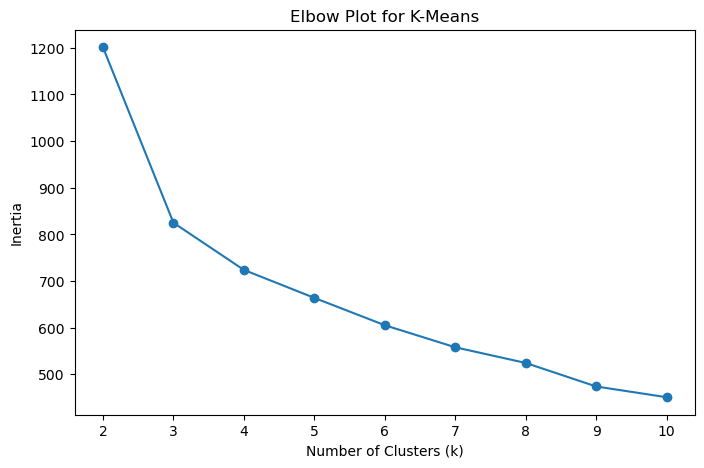

In [15]:
#elbow plot
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-Means")
plt.show()

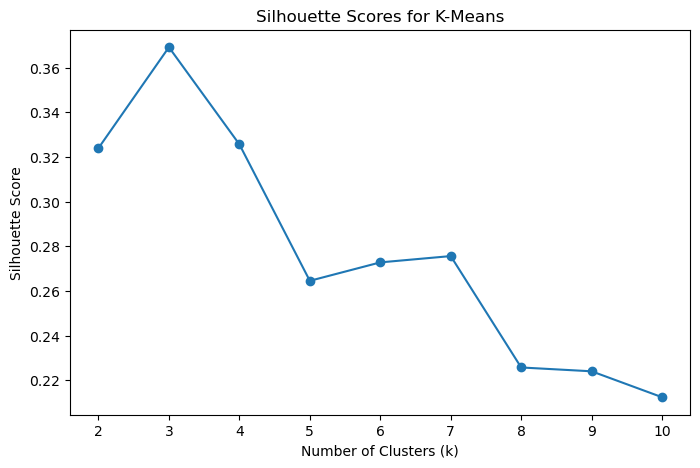

In [16]:
#silhouette plot
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.show()

In [17]:
#Choose best k
best_k = 3

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

wine_pca_df["KMeans_Cluster"] = kmeans_final.fit_predict(wine_pca_df)

wine_pca_df.head()

C:\ProgramData\anaconda3\envs\ds_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,PC1,PC2,PC3,PC4,PC5,KMeans_Cluster
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,2
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,2
2,2.516740,1.031151,0.982819,0.724902,-0.251033,2
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,2
4,1.008908,0.869831,2.026688,-0.409766,0.298458,2


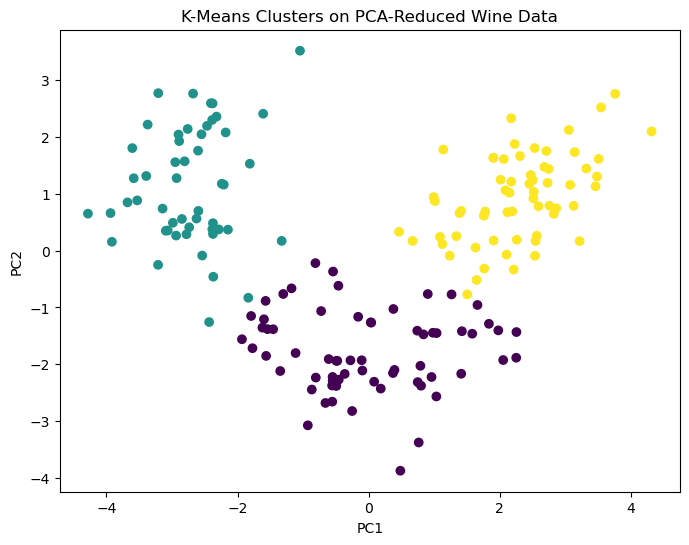

In [18]:
#Plot K-means clusters using PC1 and PC2
plt.figure(figsize=(8,6))
plt.scatter(
    wine_pca_df["PC1"],
    wine_pca_df["PC2"],
    c=wine_pca_df["KMeans_Cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-Reduced Wine Data")
plt.show()

K-means clustering was performed on the PCA-reduced dataset. Different values of k were evaluated using inertia and silhouette scores. The elbow plot was used to identify where additional clusters provided diminishing reductions in inertia, while the silhouette score was used to assess cluster separation. Based on these results, k = 3 was selected as the final clustering solution. The scatterplot of PC1 and PC2 showed that the observations formed visually distinct groups in the reduced feature space.

## Hierarchical Clustering

In [19]:
#hierarchical clustering
hc = linkage(
    wine_pca_df.drop(columns=["KMeans_Cluster"]),
    method="complete",
    metric="euclidean"
)

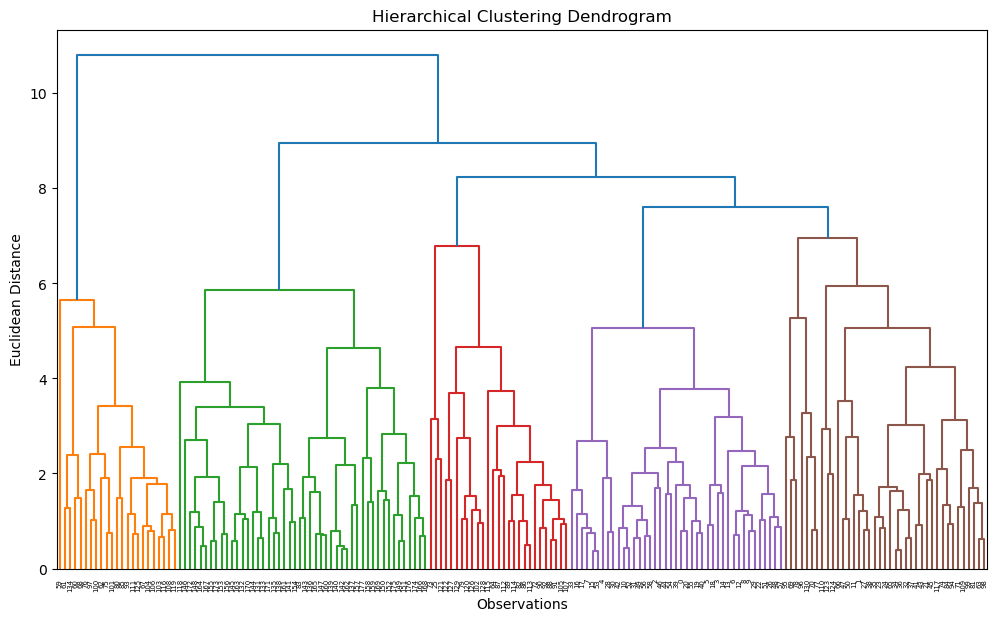

In [20]:
#plot dendrogram
plt.figure(figsize=(12,7))

dendrogram(hc)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Euclidean Distance")
plt.show()

In [21]:
#dendrogram - 3 clusters
hier_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="complete",
    metric="euclidean"
)

hier_labels = hier_model.fit_predict(
    wine_pca_df.drop(columns=["KMeans_Cluster"])
)

wine_pca_df["Hierarchical_Cluster"] = hier_labels

wine_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,KMeans_Cluster,Hierarchical_Cluster
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,2,0
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,2,0
2,2.516740,1.031151,0.982819,0.724902,-0.251033,2,0
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,2,0
4,1.008908,0.869831,2.026688,-0.409766,0.298458,2,0


In [22]:
#compare cluster counts
wine_pca_df["KMeans_Cluster"].value_counts()

KMeans_Cluster
0    65
2    62
1    51
Name: count, dtype: int64

In [23]:
wine_pca_df["Hierarchical_Cluster"].value_counts()

Hierarchical_Cluster
0    107
2     48
1     23
Name: count, dtype: int64

In [24]:
#cross-tab comparison
pd.crosstab(
    wine_pca_df["KMeans_Cluster"],
    wine_pca_df["Hierarchical_Cluster"]
)

Hierarchical_Cluster,0,1,2
KMeans_Cluster,,,
0,44,21,0
1,1,2,48
2,62,0,0


Hierarchical clustering was also applied to the PCA-reduced wine dataset using complete linkage and Euclidean distance. The dendrogram illustrated how observations merged into clusters at increasing levels of dissimilarity. A three-cluster solution was selected to compare with the k-means results. The hierarchical clustering results were broadly consistent with the k-means solution, suggesting that the underlying structure of the dataset supports approximately three clusters.

## Assumption Investigation

PCA assumes that the principal components are linear combinations of the original variables and that the most important structure in the data can be represented through variance. Because PCA is sensitive to scale, the variables were standardized before fitting the model. This ensured that variables with larger numeric ranges did not dominate the principal components.

K-means clustering assumes that clusters are roughly spherical, similar in size, and separated by Euclidean distance. The algorithm is also sensitive to initialization and outliers. To reduce initialization issues, multiple starts were used through `n_init=10`.

Hierarchical clustering does not require specifying the number of clusters before fitting, but it is sensitive to the choice of distance metric, linkage method, and variable scaling. Complete linkage was used because it tends to create compact clusters. Since Euclidean distance is scale-sensitive, standardization was necessary before clustering.

## Summary of PCA and Clustering Findings

PCA was conducted on the standardized wine dataset to reduce correlated variables into a smaller subset of principal components while retaining at least 80% of the total variance. The cumulative explained variance plot was used to determine the minimum number of components needed to meet this threshold. These components were then used as inputs for k-means and hierarchical clustering.

K-means clustering was evaluated using several values of k, including k = 3, 4, and higher values. The elbow plot and silhouette scores were used to assess the most appropriate number of clusters. A three-cluster solution provided a reasonable balance between model simplicity and cluster separation. The resulting cluster visualization using the first two principal components showed distinguishable groupings among the observations.

Hierarchical clustering using complete linkage and Euclidean distance was also performed on the PCA-reduced data. The dendrogram supported the presence of multiple meaningful clusters, and a three-cluster solution was selected for comparison with k-means. Overall, both clustering approaches suggested that the wine dataset contains a meaningful grouping structure, and PCA helped simplify the analysis by reducing dimensionality while preserving most of the original variance.

In [25]:
# Create submission file using K-means clusters
kmeans_submission = pd.DataFrame({
    "id": wine_pca_df.index,
    "Cluster": wine_pca_df["KMeans_Cluster"]
})

kmeans_submission.to_csv("wine_kmeans_submission.csv", index=False)

kmeans_submission.head()

,id,Cluster
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2


In [26]:
# Create submission file using hierarchical clusters
hierarchical_submission = pd.DataFrame({
    "id": wine_pca_df.index,
    "Cluster": wine_pca_df["Hierarchical_Cluster"]
})

hierarchical_submission.to_csv("wine_hierarchical_submission.csv", index=False)

hierarchical_submission.head()

,id,Cluster
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
